# C2 Simulation of an 2D airfoil performance

## Introduction

We are going to simulate from scratch a well known a 2D airfoil. We 
will study the [NACA 65(1)-212 airfoil](https://en.wikipedia.org/wiki/NACA_airfoil#6-series), 
typically used for axial compressors and fans.

We will use the online platform [onShape](https://en.wikipedia.org/wiki/Onshape), a 3D CAD web-based software, which integrates very smoothly with Simscale. In this
way the work flow will be contained on the cloud, and we will not depend on local installed software or computer specifications.  OnShape is not free
but there is an [educational plan](https://www.onshape.com/en/education/)





## Learning objectives

1. Learn to generate a 3D airfoil solid in **onShape** using coordinate data (CSV).
2. Understand the concept of **External Aerodynamics** and size the computational domain.
3. Configure local **Mesh Refinement** and boundary layer around the airfoil
4. Run a **simulation of aerodynamics** in an airfoil with several incidence angles.
5. Compute **aerodynamic coefficients** from the outcome of the simulations


## Previous tasks (about 2 hours)

- [ ] Create and educational account in Onshape 
- [ ] Become familiar with the platform by watching the video for [Onshape essentials webinar](https://learn.onshape.com/learn/video/onshape-essentials)
- [ ] (Optional) Take some tutorial or course from the Learning Center. For instance this [Fundamental course](https://learn.onshape.com/courses/introduction-to-part-studios)



## Making the geometry for the NACA 65(1)-212 airfoil

1. In you dashboard, create a new folder for this subject. For instance, `DFA`, or `Axial Fan`-
2. Make a new Document, named `NACA 65(1)-212`

![create.png](./images/C2_Create.png)

3. Import the CSV file for the airfoil. It is [here](./data/NACA65_1_212.csv). This imported file will be put in a tab of the project.

![import](./images/C2_import.png)

4. Add a `custom feature`. Look for the "Routing curve - Control Point Curve".

![Custom Feature](./images/C2_custom_feature.png)

5. Use this Custom Feature with the imported file (1). Click on "Proceed" (2) and the green button (3).

![RoutingCurve](./images/C2_RoutingCurve.png)

You will get something similar to that

![NACA_curve](./images/C2_Naca_curve.png)

6. `Transform` the curve to scale it for a 0.3 m chord.

![Trasnform](./images/C2_Transform.png)
![scale](./images/C2_Scale.png)

7. `Fill` the curve

![Fill](./images/C2_Fill.png)
![Filled](./images/C2_Filled.png)

8. And finally `Thicken` it 0.3 m to obtain a solid airfoil.

![Thicken](./images/C2_Thicken.png)
![Solid](./images/C2_Solid.png)

## Simulation of the airfoil



### Meshing

Now we are going to simulate the aerodynamic performance of this airfoil with Simscale

1. Sign-in in Simscale and create a `DFA` folder. Create a `New Project` in this folder. You can name it `NACA 65(1)-212`. The category should be `Machinery and Industrial Equipment`
2. The first think asked for is the `Geometry`. Click on "from Onshape` to connect with your account of the cloud service

![Geometry](./images/C2_CFD_geometry.png)

3. Navigate until the proper `Part` in the project. Import it

![Part](./images/C2_CFD_Part.png)

4. Open the geometry and Create the Simulation. Select an `Incompressible` kind with the default parameters (Turbulence model, steady steate...)

![CreateSimulation](./images/C2_CFD_CreateSimulation.png)

5. The first think will be the generation of the mesh. Click on the `Mesh` element, and select `Hex-dominant parametric` with the discretization shown in this picture. Save it. **Still don't generate** 

![Mesh1](./images/C2_CFD_Mesh1.png)

6. Open the `Background Mesh Box` element in the `Geometry primitives` section. Modify the dimensions according to this picture. In the upstream direction we
   get about 5 times the chord (1.5 m), and 15 times downstream (4.5 m), and 5 times the chord (1.5 m) in the top and bottom directions. In the $z$ direction we keep the airfoil dimensions. Save it.

![BMB](./images/C2_CFD_BMB.png) 

7. Be sure that the `Material Point` falls inside the fluid region (outside the airfoil)

![MP](./images/C2_CFD_MP.png)

8. We want to create a region around the airfoil where the mesh will be more refine. Create it by cliking on the `+` symbol in `Geometry primitives` and select `Cartesian box`. Give the dimensions of the figure and name it `Refinement box`. Save it.

![Refinement box](./images/C2_CFD_RefinementBox.png)

9. We define now the refinements. Click on `+` close to `Refinements` and select `Region refinement`. Raise the level to 4 and switch the selector close to `Refinement box`. Don't forget to save it

![levelBox](./images/C2_CFD_levelRefinementBox.png)

10. Add a `Refinement surface` with level 6 on the airfoil. Save it.

![RefinementDurface](./images/C2_CFD_RefinementSurface.png)

11. Add an `Inflate Boundary Layer` on the airfol surface with the parameters of the picture. Save it.

![BoundaryLayer](./images/C2_CFD_BoundaryLayer.png)

12. Back to the `Mesh`, it can now be generated.

![GenerateMesh](./images/C2_CFD_GenerateMesh.png)


It will take a while. In the meantime, read the [Simscale documentation about hex-dominant meshes](https://www.simscale.com/docs/simulation-setup/meshing/hex-dominant/).

After about 5-10 minutes, the mesh, with about 2 Million cells, will be ready for the simulation.

![Mesh Global](./images/C2_CFD_MeshGlobal.png)
![Mesh Detail](./images/C2_CFD_MeshDetail.png)

Since we have defined the mesh before the simulation parameters, the program propose to use the mesh as domain. Click on the proposal, and accept the reassignments of properties. Save it.

![Mesh as Domain](./images/C2_CFD_MeshAsDomain.png)

### Setup of the simulation

We want to compute the aerodynamic force and force coefficients fo this airfoil for several incidence angle. These will be the simulation data:

- Air velocity: $U = 30 \,\text{m/s}$
- Chord length: $c = 0.3\,\text{m}$
- Incidence angles: $\alpha = 0^{\circ}$, $4^{\circ}$, $8^{\circ}$, $10^{\circ}$ and $12^{\circ}$
  

1. Define the material (fluid). It will be `air`. Keep the default properties. We annotate it for future use in the Notebook 

In [1]:
rho = 1.196  # density of air in kg/m^3
nu = 1.529e-5  # kinematic viscosity of air in m^2/s

2. For the initial condition, we keep $P = 0\,\text{Pa}$, but velocity will depend on the incidence angle (we modify the air direction, not the mesh). We define two python functions that:
   - Compute Reynolds number
   - Decompose velocity in $x$ and $y$ directions

In [2]:
import numpy as np

def ReynoldsNumber(U, c, nu):
    """ 
    Return Reynolds number given the velocity, chord length and kinematic viscosity
    """
    Re = U * c / nu
    print(f"Reynolds number: Re = {Re:.2e}")
    return Re

def velocityComponents(U,alpha):
    """ 
    Return velocity components given the magnitude and the incident angle
    """
    alpha = np.radians(alpha)
    u = U * np.cos(alpha)
    v = U * np.sin(alpha)
    print(f"Velocity components: u = {u:.2f} m/s, v = {v:.2f} m/s")
    return u, v


Define the initial velocity for $\alpha = 0^\circ$, $U_x = 30 \, \text{m/s}$ and $U_y = 0 \, \text{m/s}$. Leave $k$ and $\omega$ (turbulence variables) with ts default values

3. We define the boundary conditions
   1. Define a `Custom - Freestream` boundary condition for the external surfaces in $x$ and $y$ directions.

![Free Stream](./images/C2_CFD_FreeStream.png)

   2. Define a `Wall` boundary condition on the airfoil. Rename it `Airfoil`. 

![Wall](./images/C2_CFD_Wall.png)

   3. Define a `Symmetry` boundary conditions for the front a back surfaces.

![Symmetry](./images/C2_CFD_symmetry.png)  

4. Define the monitor for aerodynamic forces in `Result control - Forces and Moments`. Assign the airfoil surface.

![Forces and Moments](./images/C2_CFD_ForcesMoments.png)

### Running the simulation

Create a new run, named `alpha_0`

![Run alpha 0](./images/C2_CFD_Run_alpha0.png)

### Post-processing

The most important outcomes are the total forces (pressure + viscous) in the $x$ and $y$ directions.

Plot these forces and download the data in a `CSV` file.

![Forces CSV](./images/C2_CFD_Forces_csv.png)

Name this file, for instance `forces_0.csv`. In this Notebook it has been stored in [`./data/C2_forces.csv`](./data/C2_forces_0.csv). 

For low values of $\alpha$ the simulation runs smoothly and the forces are very stable. But when $\alpha$ increases the simulation becomes more unstable
and the results are not that trusty. It is convenient to get an estimation of the error by computing the mean and standard deviation of the last iteration, 
say 200 over 1000, for instance. The next function can help to do that from the downloaded file, by using `pandas` that has been already used in 
the [E1 Notebook](../3_Experimental/E1_measurement_of_magnitudes.ipynb). Also, once the forces are computed, we will need to decompose in the incident velocity direction (drag) and its normal (lift) and compute aerodynamic coefficients with the errors.

In [3]:
def get_forces_from_csv(file_path):
    """ 
    Return mean forces and their standard deviation from a CSV file
    """
    import pandas as pd
    df = pd.read_csv(file_path).tail(200)
    Fx = df['TOTAL_FORCE_X'].mean()
    Fy = df['TOTAL_FORCE_Y'].mean()
    Fx_err = 2 * df['TOTAL_FORCE_X'].std() # multiplying by 2 to get a 95% confidence interval
    Fy_err = 2 * df['TOTAL_FORCE_Y'].std()
    print(f"Mean forces: Fx = {Fx:.2f} N, Fy = {Fy:.2f} N")
    print(f"Standard deviation of forces: Fx_err = {Fx_err:.2g} N, Fy_err = {Fy_err:.2g} N")
    return Fx, Fy, Fx_err, Fy_err

def LiftDragCoefficients(Fx,Fy,Fx_err,Fy_err,U,rho,c,b,alpha):
    """ 
    Return lift and drag coefficients given the forces, velocity and incident angle
    """
    alpha = np.radians(alpha)
    eps_x = Fx_err / Fx if Fx != 0 else 0
    eps_y = Fy_err / Fy if Fy != 0 else 0
    L = Fy * np.cos(alpha) - Fx * np.sin(alpha)
    L_err = np.sqrt((eps_x * L)**2 + (eps_y * L)**2)
    D = Fx * np.cos(alpha) + Fy * np.sin(alpha)
    D_err = np.sqrt((eps_x * D)**2 + (eps_y * D)**2)
    Cl = 2 * L / (rho * U**2 * c * b)
    Cl_err = 2 * L_err / (rho * U**2 * c * b)
    Cd = 2 * D / (rho * U**2 * c * b)
    Cd_err = 2 * D_err / (rho * U**2 * c * b)
    print(f"Lift: L = {L:.2f} +/- {L_err:.2f} N, Drag: D = {D:.2f} +/- {D_err:.2f} N")
    print(f"Lift coefficient: Cl = {Cl:.4f} +/- {Cl_err:.4f}, Drag coefficient: Cd = {Cd:.4f} +/- {Cd_err:.4f}")
    return Cl, Cd, Cl_err, Cd_err

We get also the Reynolds number, for reference.

In [4]:
U = 30  # velocity magnitude in m/s
c = 0.3  # chord length in m
b = 0.3  # span in m


Re = ReynoldsNumber(U=U, c=c, nu=nu);

Reynolds number: Re = 5.89e+05


### For $\alpha = 0^\circ$

In [5]:
alpha = 0  # incident angle in degrees
velocityComponents(U=U, alpha=alpha);

Velocity components: u = 30.00 m/s, v = 0.00 m/s


![U0](./images/C2_CFD_U_0.png)
![p0](./images/C2_CFD_p0.png)

In [6]:
Fx_0, Fy_0, Fx_err_0, Fy_err_0 = get_forces_from_csv('./data/C2_forces_0.csv')

Cl_0, Cd_0, Cl_err_0, Cd_err_0 = LiftDragCoefficients(Fx=Fx_0, Fy=Fy_0, Fx_err=Fx_err_0, Fy_err=Fy_err_0, U=U, rho=rho, c=c, b=b, alpha=alpha)

Mean forces: Fx = 0.56 N, Fy = 6.63 N
Standard deviation of forces: Fx_err = 1.2e-05 N, Fy_err = 0.00074 N
Lift: L = 6.63 +/- 0.00 N, Drag: D = 0.56 +/- 0.00 N
Lift coefficient: Cl = 0.1369 +/- 0.0000, Drag coefficient: Cd = 0.0115 +/- 0.0000


### For $\alpha = 4^\circ$

In [7]:
alpha = 4  # incident angle in degrees
velocityComponents(U=U, alpha=alpha);

Velocity components: u = 29.93 m/s, v = 2.09 m/s


![U4](./images/C2_CFD_U4.png)
![p4](./images/C2_CFD_p4.png)

In [8]:
Fx_4, Fy_4, Fx_err_4, Fy_err_4 = get_forces_from_csv('./data/C2_forces_4.csv')

Cl_4, Cd_4, Cl_err_4, Cd_err_4 = LiftDragCoefficients(Fx=Fx_4, Fy=Fy_4, Fx_err=Fx_err_4, Fy_err=Fy_err_4, U=U, rho=rho, c=c, b=b, alpha=alpha)

Mean forces: Fx = -0.86 N, Fy = 25.59 N
Standard deviation of forces: Fx_err = 0.00044 N, Fy_err = 0.003 N
Lift: L = 25.59 +/- 0.01 N, Drag: D = 0.92 +/- 0.00 N
Lift coefficient: Cl = 0.5283 +/- 0.0003, Drag coefficient: Cd = 0.0191 +/- 0.0000


### For $\alpha = 8^\circ$

In [9]:
alpha = 8  # incident angle in degrees
velocityComponents(U=U, alpha=alpha);

Velocity components: u = 29.71 m/s, v = 4.18 m/s


![U8](./images/C2_CFD_U8.png)
![p8](./images/C2_CFD_p8.png)

In [10]:
Fx_8, Fy_8, Fx_err_8, Fy_err_8 = get_forces_from_csv('./data/C2_forces_8.csv');

Cl_8, Cd_8, Cl_err_8, Cd_err_8 = LiftDragCoefficients(Fx=Fx_8, Fy=Fy_8, Fx_err=Fx_err_8, Fy_err=Fy_err_8, U=U, rho=rho, c=c, b=b, alpha=alpha)

Mean forces: Fx = -4.05 N, Fy = 41.54 N
Standard deviation of forces: Fx_err = 0.0079 N, Fy_err = 0.058 N
Lift: L = 41.70 +/- 0.10 N, Drag: D = 1.77 +/- 0.00 N
Lift coefficient: Cl = 0.8609 +/- 0.0021, Drag coefficient: Cd = 0.0366 +/- 0.0001


### For $\alpha = 10^\circ$

In [11]:
alpha = 10  # incident angle in degrees
velocityComponents(U=U, alpha=alpha);

Velocity components: u = 29.54 m/s, v = 5.21 m/s


![U10](./images/C2_CFD_U10.png)
![p10](./images/C2_CFD_p10.png)

In [12]:
Fx_10, Fy_10, Fx_err_10, Fy_err_10 = get_forces_from_csv('./data/C2_forces_10.csv');

Cl_10, Cd_10, Cl_err_10, Cd_err_10 = LiftDragCoefficients(Fx=Fx_10, Fy=Fy_10, Fx_err=Fx_err_10, Fy_err=Fy_err_10, U=U, rho=rho, c=c, b=b, alpha=alpha)

Mean forces: Fx = -4.25 N, Fy = 41.26 N
Standard deviation of forces: Fx_err = 0.2 N, Fy_err = 0.82 N
Lift: L = 41.37 +/- 2.09 N, Drag: D = 2.98 +/- 0.15 N
Lift coefficient: Cl = 0.8541 +/- 0.0431, Drag coefficient: Cd = 0.0614 +/- 0.0031


### For $\alpha = 12^\circ$

In [13]:
alpha = 12  # incident angle in degrees
velocityComponents(U=U, alpha=alpha);

Velocity components: u = 29.34 m/s, v = 6.24 m/s


![U12](./images/C2_CFD_U12.png)
![p12](./images/C2_CFD_p12.png)

In [14]:
Fx_12, Fy_12, Fx_err_12, Fy_err_12 = get_forces_from_csv('./data/C2_forces_12.csv');

Cl_12, Cd_12, Cl_err_12, Cd_err_12 = LiftDragCoefficients(Fx=Fx_12, Fy=Fy_12, Fx_err=Fx_err_12, Fy_err=Fy_err_12, U=U, rho=rho, c=c, b=b, alpha=alpha)

Mean forces: Fx = -3.50 N, Fy = 41.69 N
Standard deviation of forces: Fx_err = 0.18 N, Fy_err = 2.2 N
Lift: L = 41.50 +/- 3.00 N, Drag: D = 5.25 +/- 0.38 N
Lift coefficient: Cl = 0.8568 +/- 0.0619, Drag coefficient: Cd = 0.1084 +/- 0.0078


Finally, we plot the results

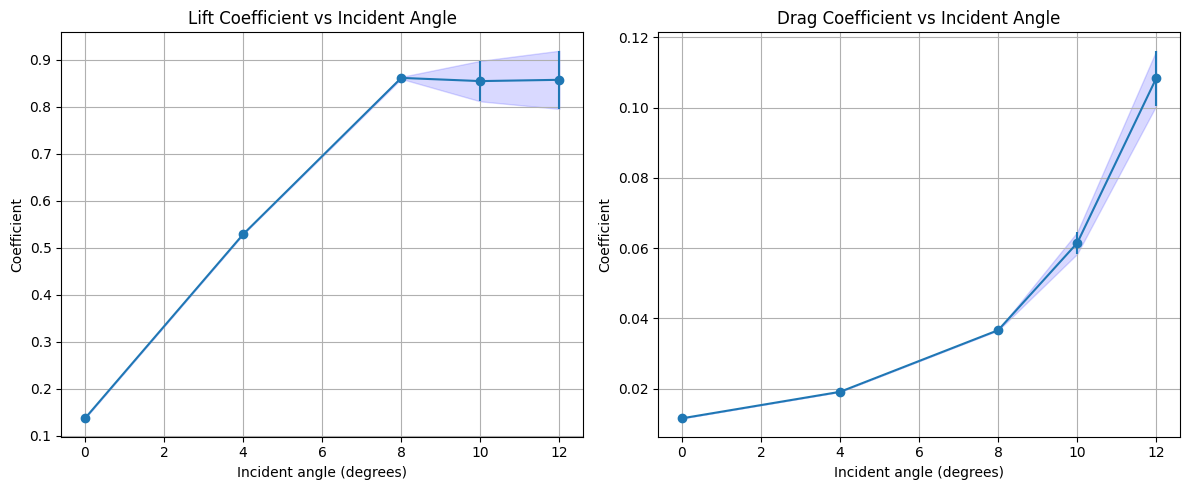

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
angles = [0, 4, 8, 10, 12]
Cl_values = np.array([Cl_0, Cl_4, Cl_8, Cl_10, Cl_12])
Cl_errors = np.array([Cl_err_0, Cl_err_4, Cl_err_8, Cl_err_10, Cl_err_12])
Cd_values = np.array([Cd_0, Cd_4, Cd_8, Cd_10, Cd_12])
Cd_errors = np.array([Cd_err_0, Cd_err_4, Cd_err_8, Cd_err_10, Cd_err_12])
ax1.errorbar(angles, Cl_values, yerr=Cl_errors, fmt='o-', label='Lift coefficient')
ax1.fill_between(angles, Cl_values - Cl_errors, Cl_values + Cl_errors, 
                 color='blue', alpha=0.15, label='95% Confidence Band')
ax2.errorbar(angles, Cd_values, yerr=Cd_errors, fmt='o-', label='Drag coefficient')
ax2.fill_between(angles, Cd_values - Cd_errors, Cd_values + Cd_errors, 
                 color='blue', alpha=0.15, label='95% Confidence Band')
ax1.set_xlabel('Incident angle (degrees)')
ax1.set_ylabel('Coefficient')
ax1.set_title('Lift Coefficient vs Incident Angle')
ax2.set_xlabel('Incident angle (degrees)')
ax2.set_ylabel('Coefficient')
ax2.set_title('Drag Coefficient vs Incident Angle')
ax1.grid()
ax2.grid()
plt.tight_layout()

## Some questions

Why do you think that this NACA 65 airfoil is able to generate a positive Lift force even for $\alpha = 0$? What geometric feature is responsible for that?


___

Why do you that we need to extend the Background Boundary domain so much as 15 times the chord length in the downstream direction? What issue would we find if we
place this boundary too close to the trailing edge?

___

Describe in your words the role of the Reynolds number. Have a look at the [data base for this airfoil](http://airfoiltools.com/airfoil/details?airfoil=naca651212-il#polars). The Reynolds number has a great influence on the airfoil performance

___

What happens for $\alpha > 8$?

___